In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

fred_api = 'add api here'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install fredapi

In [ ]:
from fredapi import Fred

fred = Fred(api_key=fred_api)
brent = fred.get_series('POILBREUSDM', observation_start='1990-01-01')
brent = brent.asfreq('MS')  # monthly start frequency
brent.name = 'Brent'
brent.dropna(inplace=True)

In [ ]:
brent.head()

,Brent
2003-01-01,30.808696
2003-02-01,32.662500
2003-03-01,30.168095
2003-04-01,25.035000
2003-05-01,25.714545


In [ ]:
brent.describe()

,Brent
count,277.000000
mean,72.278666
std,25.257465
min,25.035000
25%,54.839091
50%,70.340000
75%,88.947727
max,133.585217


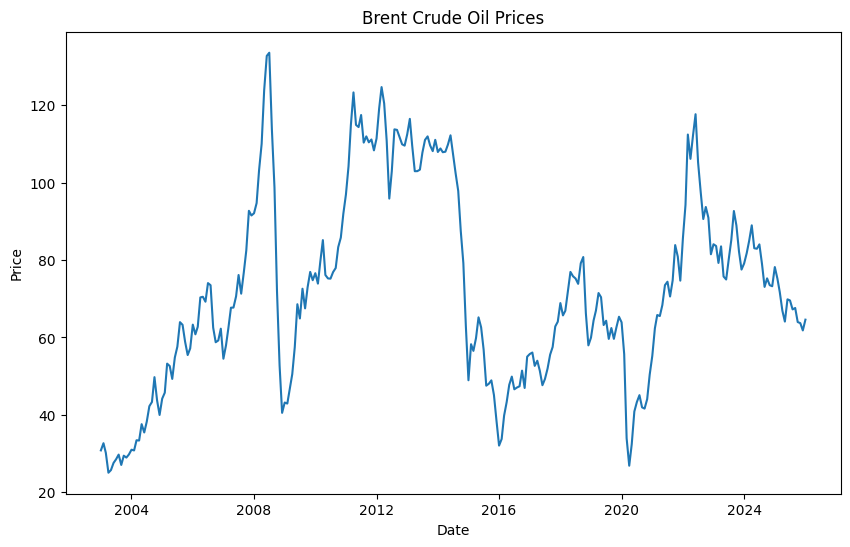

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(brent.index, brent.values)
plt.title('Brent Crude Oil Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

Initial Prophet model:

In [ ]:
import pandas as pd
from prophet import Prophet

# Reset index and rename columns
df_brent = brent.reset_index()
df_brent.columns = ["ds", "y"]

df_brent.head()

,ds,y
0,2003-01-01,30.808696
1,2003-02-01,32.662500
2,2003-03-01,30.168095
3,2003-04-01,25.035000
4,2003-05-01,25.714545


In [ ]:
train = df_brent.iloc[:-24]
test  = df_brent.iloc[-24:]

In [ ]:
model = Prophet(
    growth="linear",
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train)


In [ ]:
future = model.make_future_dataframe(
    periods=len(test),
    freq="MS"
)

forecast = model.predict(future)


In [ ]:
forecast_test = forecast.set_index("ds").loc[test["ds"]]
y_pred = forecast_test["yhat"]

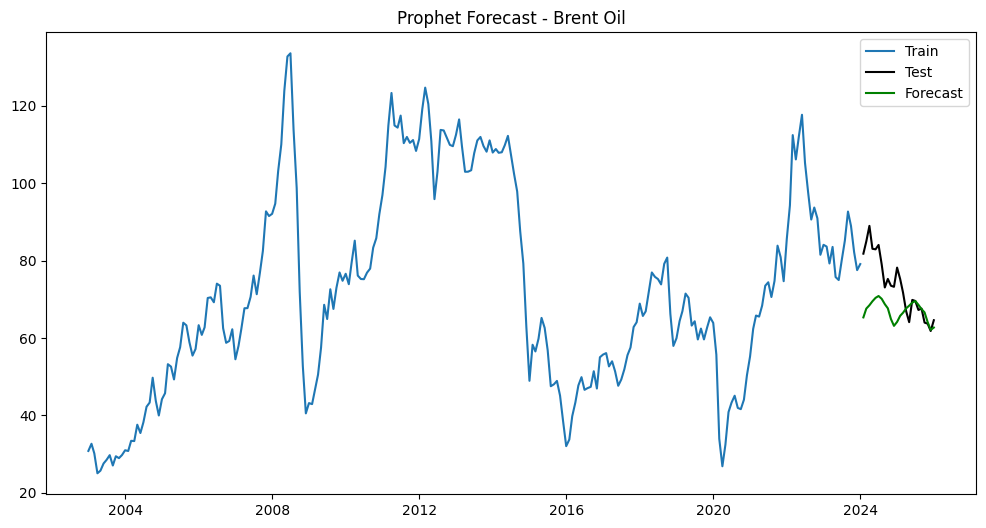

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(train["ds"], train["y"], label="Train")
plt.plot(test["ds"], test["y"], label="Test", color="black")
plt.plot(forecast_test.index, y_pred, label="Forecast", color="green")
plt.legend()
plt.title("Prophet Forecast - Brent Oil")
plt.show()


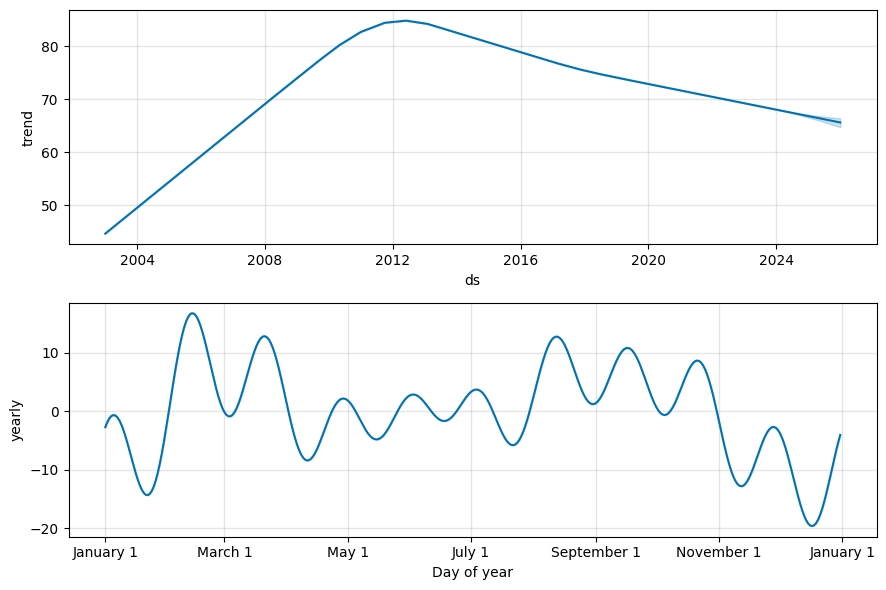

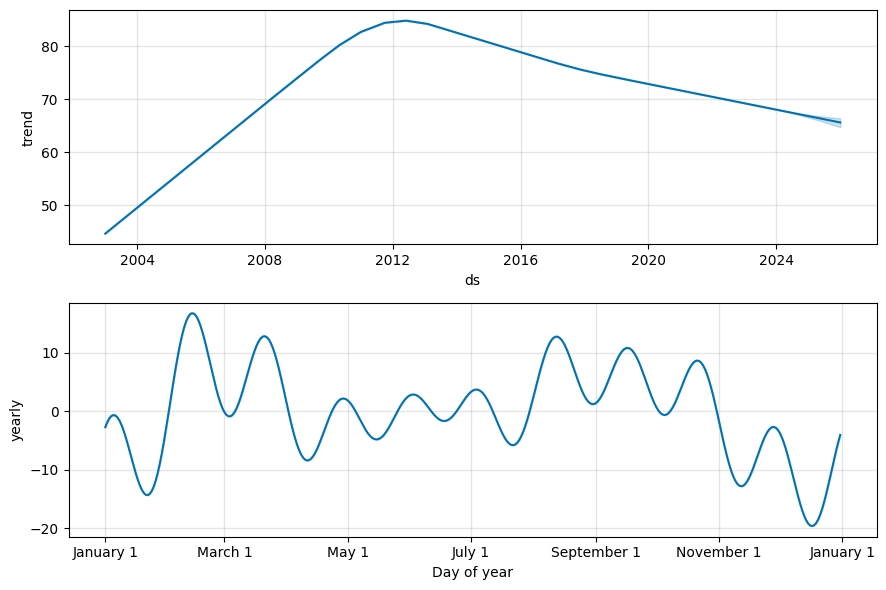

In [ ]:
model.plot_components(forecast)

In [ ]:
# Ensure alignment
y_test = test.set_index("ds")["y"]
y_pred = y_pred.loc[y_test.index]

# MAE
mae = np.mean(np.abs(y_test - y_pred))

# MSE
mse = np.mean((y_test - y_pred)**2)

# MAPE
mape = np.mean(
    np.abs((y_test - y_pred) / y_test)
) * 100

# sMAPE
smape = np.mean(
    2 * np.abs(y_test - y_pred) /
    (np.abs(y_test) + np.abs(y_pred))
) * 100

# MASE (seasonal naive benchmark, monthly lag=12)
seasonal_lag = 12
y_train = train.set_index("ds")["y"]

naive_forecast = y_train.shift(seasonal_lag)
naive_errors = y_train[seasonal_lag:] - naive_forecast[seasonal_lag:]
mae_naive = np.mean(np.abs(naive_errors))

mase = mae / mae_naive

print("MAE:", round(mae, 2))
print("MSE:", round(mse, 2))
print("MAPE:", round(mape, 2))
print("sMAPE:", round(smape, 2))
print("MASE:", round(mase, 2))

MAE: 7.26
MSE: 91.08
MAPE: 9.18
sMAPE: 9.91
MASE: 0.36


Extension: Tune parameters and add regressor

## GARCH Model for Volatility Modeling

GARCH (Generalized Autoregressive Conditional Heteroskedasticity) model is used to capture the volatility clustering phenomenon in crude oil prices.

- Prophet: Predicts price mean (trend + seasonality)
- GARCH: Predicts price volatility (conditional variance)

In [ ]:
!pip install arch

Returns Statistics:
count    276.000000
mean       0.268234
std        8.891224
min      -49.501004
25%       -4.555144
50%        1.297308
75%        6.386506
max       23.131376
Name: Returns, dtype: float64


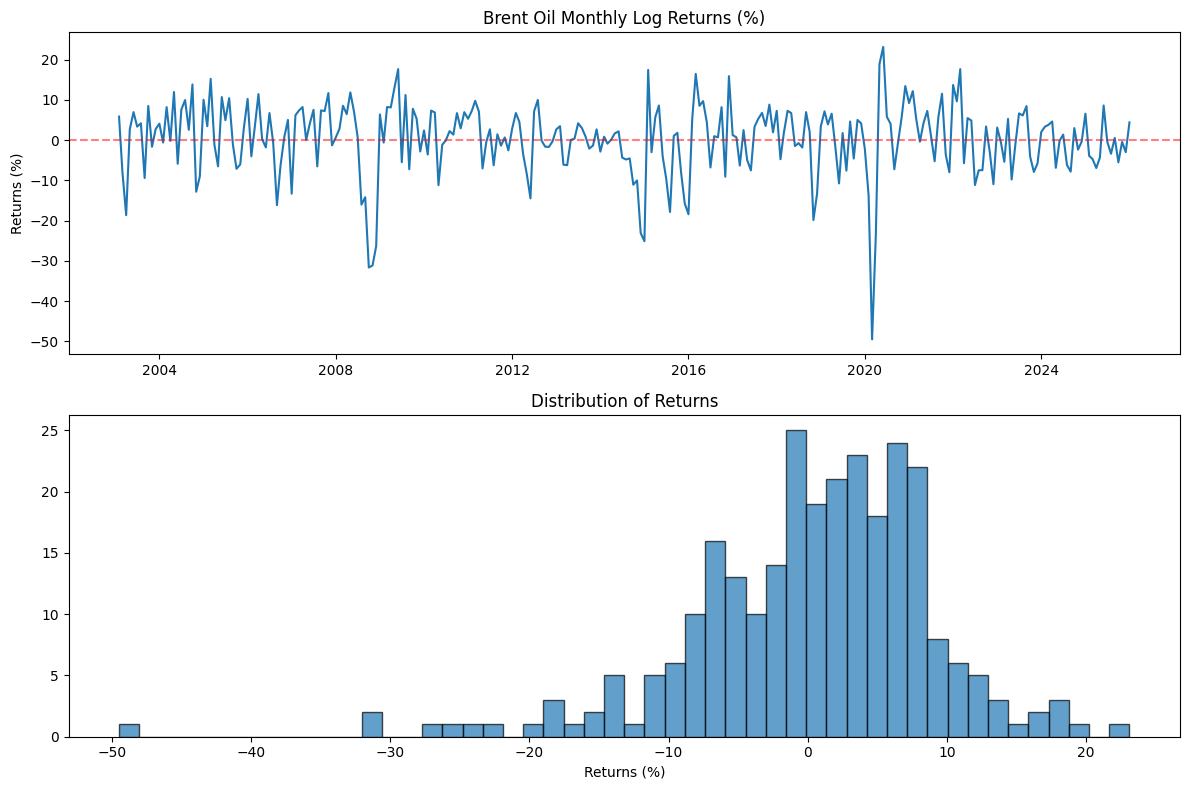

In [ ]:
from arch import arch_model

# Calculate log returns (GARCH works better with returns)
returns = 100 * np.log(brent / brent.shift(1)).dropna()
returns.name = 'Returns'

print("Returns Statistics:")
print(returns.describe())

# Plot returns
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(returns.index, returns.values)
axes[0].set_title('Brent Oil Monthly Log Returns (%)')
axes[0].set_ylabel('Returns (%)')
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)

axes[1].hist(returns, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Returns')
axes[1].set_xlabel('Returns (%)')

plt.tight_layout()
plt.show()

In [ ]:
# Train/Test split for GARCH (same 24-month test period)
returns_train = returns.iloc[:-24]
returns_test = returns.iloc[-24:]

print(f"Training samples: {len(returns_train)}")
print(f"Test samples: {len(returns_test)}")

Training samples: 252
Test samples: 24


In [ ]:
# Fit GARCH(1,1) model
# mean='AR' uses AR(1) for mean equation, vol='GARCH' for variance equation
garch_model = arch_model(
    returns_train,
    mean='AR',       # AR(1) mean model
    lags=1,          # AR lag
    vol='GARCH',     # GARCH volatility model
    p=1,             # GARCH p (lag of squared residuals)
    q=1,             # GARCH q (lag of variance)
    dist='t'         # Student's t distribution (better for fat tails)
)

garch_result = garch_model.fit(disp='off')
print(garch_result.summary())

                              AR - GARCH Model Results                              
Dep. Variable:                      Returns   R-squared:                       0.089
Mean Model:                              AR   Adj. R-squared:                  0.085
Vol Model:                            GARCH   Log-Likelihood:               -876.235
Distribution:      Standardized Student's t   AIC:                           1764.47
Method:                  Maximum Likelihood   BIC:                           1785.62
                                              No. Observations:                  251
Date:                      Sat, Mar 07 2026   Df Residuals:                      249
Time:                              04:12:16   Df Model:                            2
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
Const     

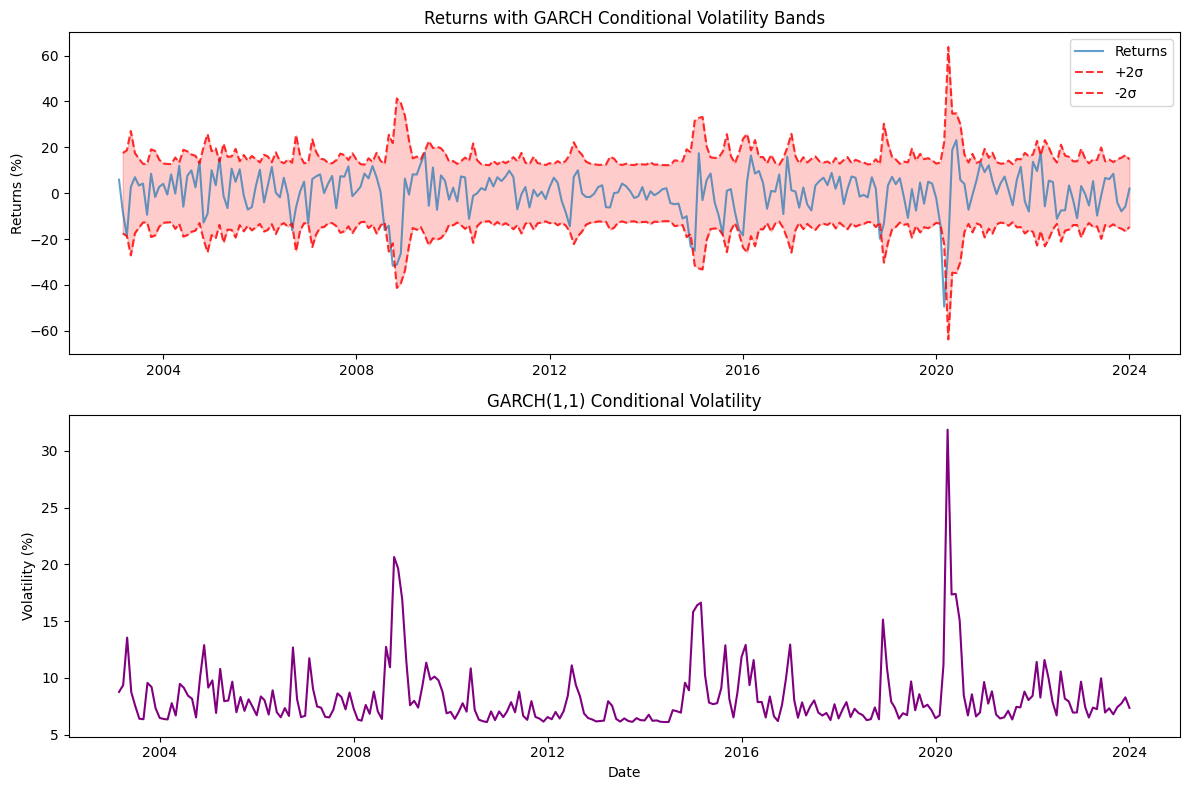

In [ ]:
# Plot conditional volatility
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Returns with conditional volatility bands
cond_vol = garch_result.conditional_volatility
axes[0].plot(returns_train.index, returns_train.values, label='Returns', alpha=0.7)
axes[0].plot(cond_vol.index, 2*cond_vol, 'r--', label='+2σ', alpha=0.8)
axes[0].plot(cond_vol.index, -2*cond_vol, 'r--', label='-2σ', alpha=0.8)
axes[0].fill_between(cond_vol.index, -2*cond_vol, 2*cond_vol, alpha=0.2, color='red')
axes[0].set_title('Returns with GARCH Conditional Volatility Bands')
axes[0].set_ylabel('Returns (%)')
axes[0].legend()

# Conditional volatility over time
axes[1].plot(cond_vol.index, cond_vol, color='purple')
axes[1].set_title('GARCH(1,1) Conditional Volatility')
axes[1].set_ylabel('Volatility (%)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

In [ ]:
# GARCH Forecast - Rolling window approach
# Re-estimate model at each step for more accurate forecasts

rolling_predictions = []
rolling_variance = []

for i in range(len(returns_test)):
    # Use all data up to current point
    train_data = returns.iloc[:len(returns_train) + i]

    # Fit GARCH model
    model = arch_model(train_data, mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='t')
    model_fit = model.fit(disp='off', show_warning=False)

    # 1-step ahead forecast
    pred = model_fit.forecast(horizon=1)
    rolling_predictions.append(pred.mean.values[-1, 0])
    rolling_variance.append(pred.variance.values[-1, 0])

# Convert to series
garch_mean_forecast = pd.Series(rolling_predictions, index=returns_test.index)
garch_var_forecast = pd.Series(rolling_variance, index=returns_test.index)
garch_vol_forecast = np.sqrt(garch_var_forecast)

print("GARCH Rolling Forecast Complete!")

GARCH Rolling Forecast Complete!


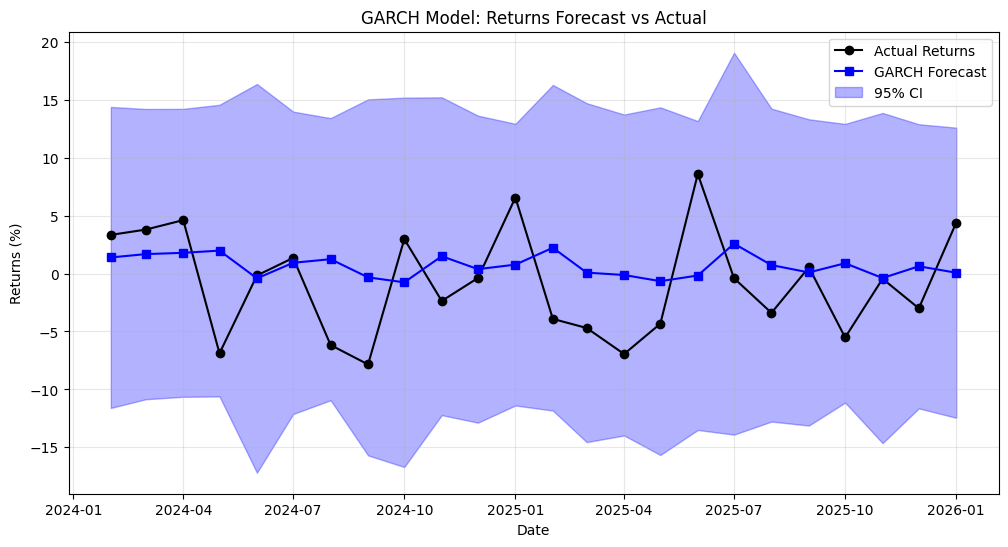

In [ ]:
# Plot GARCH forecast vs actual returns
plt.figure(figsize=(12, 6))
plt.plot(returns_test.index, returns_test.values, label='Actual Returns', color='black', marker='o')
plt.plot(returns_test.index, garch_mean_forecast.values, label='GARCH Forecast', color='blue', marker='s')
plt.fill_between(
    returns_test.index,
    garch_mean_forecast - 2*garch_vol_forecast,
    garch_mean_forecast + 2*garch_vol_forecast,
    alpha=0.3, color='blue', label='95% CI'
)
plt.title('GARCH Model: Returns Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Returns (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# GARCH Model Evaluation Metrics
garch_mae = np.mean(np.abs(returns_test - garch_mean_forecast))
garch_mse = np.mean((returns_test - garch_mean_forecast)**2)
garch_rmse = np.sqrt(garch_mse)

# Avoid division by zero for MAPE
mask = returns_test != 0
garch_mape = np.mean(np.abs((returns_test[mask] - garch_mean_forecast[mask]) / returns_test[mask])) * 100

print("=" * 50)
print("GARCH Model - Returns Forecast Metrics")
print("=" * 50)
print(f"MAE:  {garch_mae:.4f}")
print(f"MSE:  {garch_mse:.4f}")
print(f"RMSE: {garch_rmse:.4f}")
print(f"MAPE: {garch_mape:.2f}%")

GARCH Model - Returns Forecast Metrics
MAE:  4.0695
MSE:  23.5841
RMSE: 4.8563
MAPE: 129.76%


## Model Comparison: Prophet vs GARCH

Comparing the two models:
- **Prophet**: Forecasts price level (trend + seasonality)
- **GARCH**: Forecasts returns and volatility (conditional variance)

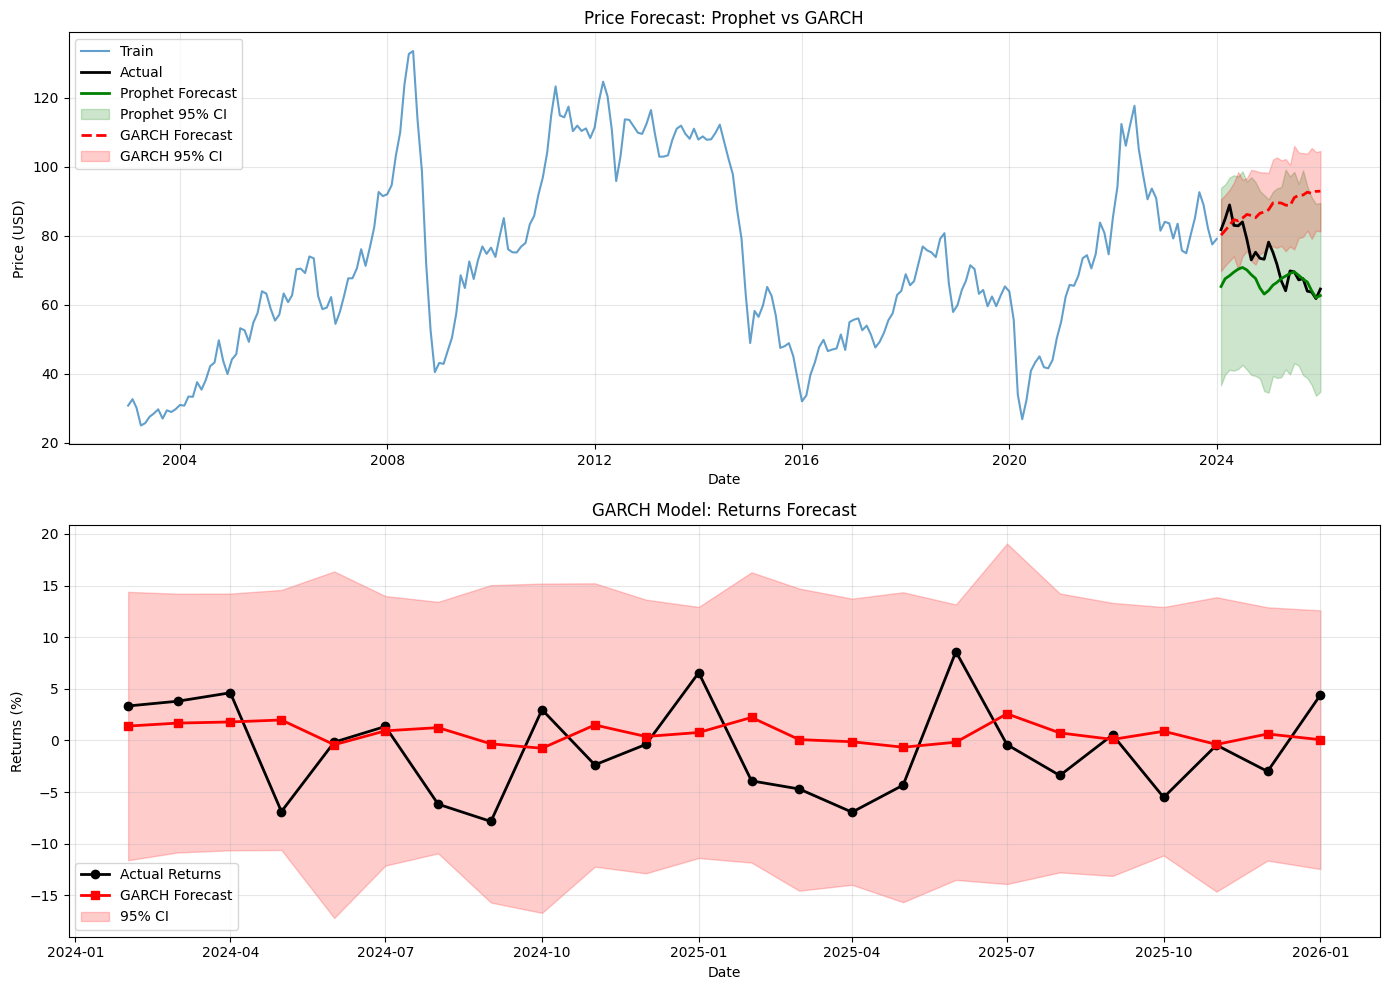

In [ ]:
# Convert GARCH returns forecast to price levels
# Start from last training price, apply cumulative returns
last_train_price = train["y"].iloc[-1]
garch_price_forecast = last_train_price * np.exp(np.cumsum(garch_mean_forecast.values / 100))
garch_price_std = garch_price_forecast * garch_vol_forecast.values / 100

# Side-by-side comparison of Prophet and GARCH forecasts
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Top: Price Forecast (Prophet + GARCH) ---
axes[0].plot(train["ds"], train["y"], label="Train", alpha=0.7)
axes[0].plot(test["ds"], test["y"], label="Actual", color="black", linewidth=2)

# Prophet forecast
axes[0].plot(test["ds"], y_pred.values, label="Prophet Forecast", color="green", linewidth=2)
axes[0].fill_between(
    test["ds"],
    forecast.set_index("ds").loc[test["ds"]]["yhat_lower"],
    forecast.set_index("ds").loc[test["ds"]]["yhat_upper"],
    alpha=0.2, color="green", label="Prophet 95% CI"
)

# GARCH forecast (converted to price)
axes[0].plot(test["ds"], garch_price_forecast, label="GARCH Forecast", color="red", linewidth=2, linestyle="--")
axes[0].fill_between(
    test["ds"],
    garch_price_forecast - 2*garch_price_std,
    garch_price_forecast + 2*garch_price_std,
    alpha=0.2, color="red", label="GARCH 95% CI"
)

axes[0].set_title("Price Forecast: Prophet vs GARCH")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Price (USD)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Bottom: GARCH Returns Forecast ---
axes[1].plot(returns_test.index, returns_test.values, label="Actual Returns", color="black", linewidth=2, marker='o')
axes[1].plot(returns_test.index, garch_mean_forecast.values, label="GARCH Forecast", color="red", linewidth=2, marker='s')
axes[1].fill_between(
    returns_test.index,
    garch_mean_forecast - 2*garch_vol_forecast,
    garch_mean_forecast + 2*garch_vol_forecast,
    alpha=0.2, color="red", label="95% CI"
)
axes[1].set_title("GARCH Model: Returns Forecast")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Returns (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Model Comparison Summary
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

print("\n--- Prophet Model (Price Forecast) ---")
print(f"MAE:   ${mae:.2f}")
print(f"MAPE:  {mape:.2f}%")
print(f"MASE:  {mase:.2f}")

print("\n--- GARCH Model (Returns Forecast) ---")
print(f"MAE:   {garch_mae:.4f}%")
print(f"RMSE:  {garch_rmse:.4f}%")

print("\n--- Model Characteristics ---")
print("Prophet: Better for trend and seasonality, point forecasts")
print("GARCH:   Better for volatility clustering, risk estimation")
print("Combined: Prophet mean + GARCH volatility for dynamic intervals")

MODEL COMPARISON SUMMARY

--- Prophet Model (Price Forecast) ---
MAE:   $7.26
MAPE:  9.18%
MASE:  0.36

--- GARCH Model (Returns Forecast) ---
MAE:   4.0695%
RMSE:  4.8563%

--- Model Characteristics ---
Prophet: Better for trend and seasonality, point forecasts
GARCH:   Better for volatility clustering, risk estimation
Combined: Prophet mean + GARCH volatility for dynamic intervals


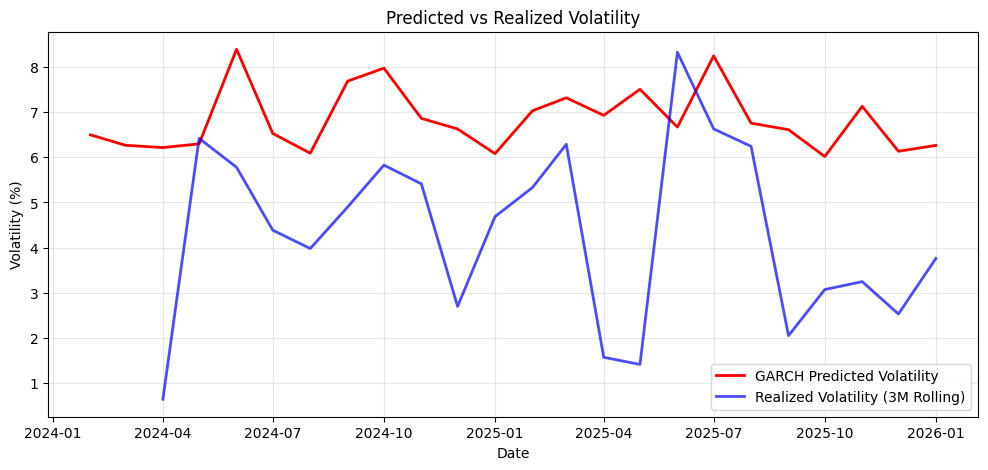

Volatility Forecast Correlation: 0.337


In [ ]:
# Volatility Analysis: Compare realized vs predicted volatility
realized_vol = returns_test.rolling(3).std()  # 3-month rolling volatility

plt.figure(figsize=(12, 5))
plt.plot(returns_test.index, garch_vol_forecast.values, label='GARCH Predicted Volatility', color='red', linewidth=2)
plt.plot(returns_test.index, realized_vol.values, label='Realized Volatility (3M Rolling)', color='blue', linewidth=2, alpha=0.7)
plt.title('Predicted vs Realized Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Volatility forecast accuracy
vol_correlation = np.corrcoef(garch_vol_forecast.values[2:], realized_vol.dropna().values)[0,1]
print(f"Volatility Forecast Correlation: {vol_correlation:.3f}")